In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from pathlib import Path
import pynapple as nap

from scipy.stats import gaussian_kde

from spatial_manifolds.data.binning import get_bin_config
from spatial_manifolds.data.loading import load_session
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2


In [2]:
mouse = 0
day = 0
session_type = 'OF1'
sorter = 'kilosort4'
storage = Path('/Users/harryclark/Downloads/COHORT12/')

alpha = 0.001
n_jobs = 8
n_shuffles = 100
seed = 1
class Args:
    def __init__(self,mouse,day,session_type,sorter,storage,alpha,n_jobs,n_shuffles,seed):
        self.mouse = mouse
        self.day = day
        self.session_type = session_type
        self.sorter = sorter
        self.storage = storage
        self.alpha = alpha
        self.n_jobs = n_jobs
        self.n_shuffles = n_shuffles
        self.seed = seed
args = Args(mouse,day,session_type,sorter,storage,alpha,n_jobs,n_shuffles,seed)

In [3]:
def load_cluster_locations(clusters, cells):
    for column in ['coord_SCs_x', 'coord_SCs_y', 'coord_SCs_z', 'coord_probe_x', 'coord_probe_y','brain_region']:
        vals = []
        for id in cells.cluster_id:
            vals.append(clusters[column][id])
        cells[column] = vals
    return cells

In [4]:
# Load session
gcs_ = pd.DataFrame()
ngs_ = pd.DataFrame()
gcs_and_ngs_ = pd.DataFrame()
ns_ = pd.DataFrame()
sc_ = pd.DataFrame()
ngs_ns_ = pd.DataFrame()
all_ = pd.DataFrame()
others_ = pd.DataFrame()

mouse_days = {
    20: [14,15,16,17,18,19,20,21,22,23,24,25,26],
    21: [15,16,17,18,19,20,21,22,23,24,25,26],
    22: [33,34,35,36,37,38,39,40,41],
    25: [16,17,18,19,20,21,22,23,24,25],
    26: [11,12,13,14,15,16,17,18,19],
    27: [16,17,18,19,20,21,22,23,24,26],
    28: [16,17,18,19,20,21,22,23,25],
    29: [16,17,18,19,20,21,22,23,25],
}

#mouse_days = {
#    26: [13,14,15,16,17,18,19]
#}

for mouse, days in mouse_days.items():
    for day in days:

        print(f"Processing M{mouse} D{day:02}...")

        gcs, ngs, all_cells = classify_cells_both_sessions(
            mouse, day, percentile_threshold=95, source_path=None, verbose=False,
        )
        others = all_cells[~all_cells.index.isin(gcs.index) & ~all_cells.index.isin(ngs.index)]

        gcs    = gcs.copy()
        ngs    = ngs.copy()
        others = others.copy()

        gcs['cell_type']    = 'GC'
        ngs['cell_type']    = 'NG'
        others['cell_type'] = 'Other'

        tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(mouse, day, apply_zscore=False, apply_guassian_filter=False)

        if len(gcs) != 0:            
            for idx, example_cluster_id in enumerate(gcs.cluster_id):
                print(f"\nMouse: {mouse}, Day: {day}, Cluster: {example_cluster_id}")
                last_ephys_time_bin = clusters[clusters.index[0]].count(bin_size=time_bs, time_units = 'ms').index[-1]

                # time binned variables for later
                ep = nap.IntervalSet(start=0, end=last_ephys_time_bin, time_units = 's')
                speed_in_time = np.array(beh['S'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep))
                dt_in_time = np.array(beh['travel'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep)-((beh['trial_number'][0]-1)*tl))
                pos_in_time = dt_in_time%tl
                trial_number_in_time = (dt_in_time//tl)+beh['trial_number'][0]

                if np.any(np.isnan(pos_in_time)):
                    series = pd.Series(dt_in_time)
                    filled_series = series.ffill().bfill()
                    dt_in_time = np.array(filled_series)
                    pos_in_time = dt_in_time%tl
                    trial_number_in_time = (dt_in_time//tl)+beh['trial_number'][0]

                if np.any(np.isnan(speed_in_time)):
                    series = pd.Series(speed_in_time)
                    filled_series = series.ffill().bfill()
                    speed_in_time = np.array(filled_series)

                # compute the spectrogram and labels from the most adunant grid module
                peak_indices = [12, 28, 44, 60, 76]
                tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in [example_cluster_id] if cluster_id in tcs}
                tcs_to_use[1000] = tcs_to_use[example_cluster_id]

                # HACK add a little noise for cases where there is long periods of no firing
                tcs_to_use[1000] += np.random.normal(loc=0.0, scale=0.001, size=tcs_to_use[1000].shape)
                tcs_to_use[example_cluster_id] += np.random.normal(loc=0.0, scale=0.001, size=tcs_to_use[1000].shape)

                # note: labelling won't work for cells with very spikes
                results = spectral_analysis(tcs_to_use, tl, bs=bs)
                spectrograms = results[3] 
                fvalid = results[5]
                S = spectrograms.mean(0)
                max_peaks = np.argmax(S, axis=0)
                labels = np.isin(max_peaks, peak_indices).astype(int)

                # compute trial labels for task anchoring to use
                tc = tcs[example_cluster_id] # example grid cell
                tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
                tc = tc[:last_ephys_bin] # only want bins with ephys data in it
                task_anchored_labels = get_kmeans_spatial_labels(tc, labels, bs=bs, tl=tl) # reuse kmeans function to get the labels based on the task anchoring

                # compute percentage hits among labelled trials for non-beaconed and beaconed trials
                last_trial = int(last_ephys_bin/(tl/bs))
                trial_types = beh['trials'].type[:last_trial].values
                trial_performances = beh['trials'].performance[:last_trial].values

                def percentage_hits(trial_type, task_label):
                    mask = (trial_types == trial_type) & (task_anchored_labels == task_label)
                    hits = np.sum(trial_performances[mask] == 'hit')
                    total = np.sum(mask)
                    return 100 * hits / total if total > 0 else np.nan

                pct_b_1 = percentage_hits('b', 1)
                pct_nb_1 = percentage_hits('nb', 1)
                pct_b_0 = percentage_hits('b', 0)
                pct_nb_0 = percentage_hits('nb', 0)

                # Store in gcs dataframe for this cell
                gcs.loc[gcs.index[idx], 'pct_b_1'] = pct_b_1
                gcs.loc[gcs.index[idx], 'pct_nb_1'] = pct_nb_1
                gcs.loc[gcs.index[idx], 'pct_b_0'] = pct_b_0
                gcs.loc[gcs.index[idx], 'pct_nb_0'] = pct_nb_0

                print(f"Percentage hits for type='b', task_anchored_label=1: {pct_b_1:.2f}%")
                print(f"Percentage hits for type='nb', task_anchored_label=1: {pct_nb_1:.2f}%")
                print(f"Percentage hits for type='b', task_anchored_label=0: {pct_b_0:.2f}%")
                print(f"Percentage hits for type='nb', task_anchored_label=0: {pct_nb_0:.2f}%")

        if len(ngs) != 0:    
            # run analysis for each non-grid cell
            for idx, example_cluster_id in enumerate(ngs.cluster_id):
                print(f"\nMouse: {mouse}, Day: {day}, Cluster: {example_cluster_id}")
                last_ephys_time_bin = clusters[clusters.index[0]].count(bin_size=time_bs, time_units = 'ms').index[-1]

                # time binned variables for later
                ep = nap.IntervalSet(start=0, end=last_ephys_time_bin, time_units = 's')
                speed_in_time = np.array(beh['S'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep))
                dt_in_time = np.array(beh['travel'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep)-((beh['trial_number'][0]-1)*tl))
                pos_in_time = dt_in_time%tl
                trial_number_in_time = (dt_in_time//tl)+beh['trial_number'][0]

                if np.any(np.isnan(pos_in_time)):
                    series = pd.Series(dt_in_time)
                    filled_series = series.ffill().bfill()
                    dt_in_time = np.array(filled_series)
                    pos_in_time = dt_in_time%tl
                    trial_number_in_time = (dt_in_time//tl)+beh['trial_number'][0]

                if np.any(np.isnan(speed_in_time)):
                    series = pd.Series(speed_in_time)
                    filled_series = series.ffill().bfill()
                    speed_in_time = np.array(filled_series)

                # compute the spectrogram and labels from the most adunant grid module
                peak_indices = [12, 28, 44, 60, 76]
                tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in [example_cluster_id] if cluster_id in tcs}
                tcs_to_use[1000] = tcs_to_use[example_cluster_id]

                # HACK add a little noise for cases where there is long periods of no firing
                tcs_to_use[1000] += np.random.normal(loc=0.0, scale=0.001, size=tcs_to_use[1000].shape)
                tcs_to_use[example_cluster_id] += np.random.normal(loc=0.0, scale=0.001, size=tcs_to_use[1000].shape)

                # note: labelling won't work for cells with very spikes
                results = spectral_analysis(tcs_to_use, tl, bs=bs)
                spectrograms = results[3] 
                fvalid = results[5]
                S = spectrograms.mean(0)
                max_peaks = np.argmax(S, axis=0)
                labels = np.isin(max_peaks, peak_indices).astype(int)
                
                # compute trial labels for task anchoring to use
                tc = tcs[example_cluster_id]
                tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
                tc = tc[:last_ephys_bin]
                task_anchored_labels = get_kmeans_spatial_labels(tc, labels, bs=bs, tl=tl)

                last_trial = int(last_ephys_bin/(tl/bs))
                trial_types = beh['trials'].type[:last_trial].values
                trial_performances = beh['trials'].performance[:last_trial].values

                def percentage_hits(trial_type, task_label):
                    mask = (trial_types == trial_type) & (task_anchored_labels == task_label)
                    hits = np.sum(trial_performances[mask] == 'hit')
                    total = np.sum(mask)
                    return 100 * hits / total if total > 0 else np.nan

                ngs.loc[ngs.index[idx], 'pct_b_1'] = percentage_hits('b', 1)
                ngs.loc[ngs.index[idx], 'pct_nb_1'] = percentage_hits('nb', 1)
                ngs.loc[ngs.index[idx], 'pct_b_0'] = percentage_hits('b', 0)
                ngs.loc[ngs.index[idx], 'pct_nb_0'] = percentage_hits('nb', 0)

        # bring everything back
        gcs_ = pd.concat([gcs_, gcs], ignore_index=True)
        ngs_ = pd.concat([ngs_, ngs], ignore_index=True)       
        others_ = pd.concat([others_, others], ignore_index=True)
        all_ = pd.concat([all_, all_cells], ignore_index=True)

print(f'there are this many cells at the moment, {len(all_)}')
print(f'there are this many gcs at the moment, {len(gcs_)}')
print(f'there are this many ngs at the moment, {len(ngs_)}')
print(f'there are this many others at the moment, {len(others_)}')

Processing M20 D14...

Mouse: 20, Day: 14, Cluster: 34
Percentage hits for type='b', task_anchored_label=1: 81.82%
Percentage hits for type='nb', task_anchored_label=1: 23.26%
Percentage hits for type='b', task_anchored_label=0: 84.21%
Percentage hits for type='nb', task_anchored_label=0: 25.00%

Mouse: 20, Day: 14, Cluster: 103
Percentage hits for type='b', task_anchored_label=1: 91.55%
Percentage hits for type='nb', task_anchored_label=1: 29.51%
Percentage hits for type='b', task_anchored_label=0: 68.42%
Percentage hits for type='nb', task_anchored_label=0: 18.52%

Mouse: 20, Day: 14, Cluster: 400
Percentage hits for type='b', task_anchored_label=1: 77.78%
Percentage hits for type='nb', task_anchored_label=1: 9.52%
Percentage hits for type='b', task_anchored_label=0: 84.00%
Percentage hits for type='nb', task_anchored_label=0: 27.66%

Mouse: 20, Day: 14, Cluster: 412
Percentage hits for type='b', task_anchored_label=1: 92.86%
Percentage hits for type='nb', task_anchored_label=1: 27.2


Beaconed: mixed model summary
          Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: pct_hits  
No. Observations:  1336    Method:             ML        
No. Groups:        8       Scale:              91.9494   
Min. group size:   22      Log-Likelihood:     -5023.5291
Max. group size:   351     Converged:          No        
Mean group size:   167.0                                 
---------------------------------------------------------
               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------
Intercept      79.104    1.741 45.441 0.000 75.692 82.516
C(label)[T.1]   1.684    0.527  3.197 0.001  0.652  2.717
cluster Var     0.196                                    
day Var       180.173    2.556                           


Non-beaconed: mixed model summary
          Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: pct_hits  
No. Observations:  1383  

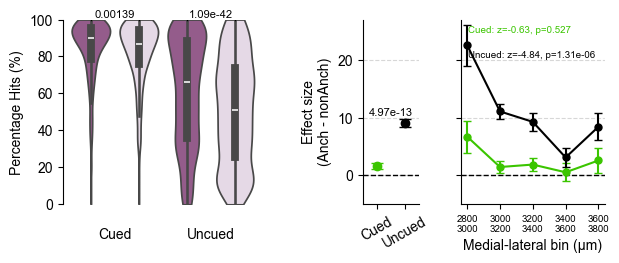

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# Build long-form DataFrame for seaborn and mixed models
records = []
for _, row in gcs_.iterrows():
    for trial_type in ['b', 'nb']:
        for label in [0, 1]:
            col = f'pct_{trial_type}_{label}'
            if col not in row or pd.isna(row[col]):
                continue
            records.append({
                'pct_hits': row[col],
                'trial_type': trial_type,
                'label': label,
                'condition': f'{trial_type}, label={label}',
                'mouse': row.get('mouse', np.nan),
                'day': row.get('day', np.nan),
                'cluster_id': row.get('cluster_id', np.nan),
            })

df_plot = pd.DataFrame.from_records(records)

# Ensure categorical ordering: b,label=1; b,label=0; nb,label=1; nb,label=0
order = ['b, label=1', 'b, label=0', 'nb, label=1', 'nb, label=0']
df_plot['condition'] = pd.Categorical(df_plot['condition'], categories=order, ordered=True)

# Color mapping: label 0 -> #e7d7e8, label 1 -> #9d5391
palette = {
    'b, label=0':  '#e7d7e8',
    'b, label=1':  '#9d5391',
    'nb, label=0': '#e7d7e8',
    'nb, label=1': '#9d5391',
}

# Colors for Cued / Uncued
trial_colors = {'Cued': '#3bc500', 'Uncued': 'black'}

# ----- Mixed models for comparisons within beaconed and non-beaconed -----
p_b = np.nan
p_nb = np.nan
eff_b = np.nan
eff_nb = np.nan
se_b = np.nan
se_nb = np.nan

def fit_lmm_trialtype(df_subset, trial_label):
    df_mod = df_subset.dropna(subset=['pct_hits', 'mouse', 'day', 'cluster_id']).copy()
    if df_mod['label'].nunique() < 2:
        print(f"{trial_label}: not enough data for both labels")
        return np.nan, np.nan, np.nan
    try:
        md = smf.mixedlm(
            'pct_hits ~ C(label)',
            df_mod,
            groups=df_mod['mouse'],
            vc_formula={
                'day': '0 + C(day)',
                'cluster': '0 + C(cluster_id)',
            },
        )
        m_fit = md.fit(reml=False, method='lbfgs')
        print(f"\n{trial_label}: mixed model summary")
        print(m_fit.summary())

        term = 'C(label)[T.1]'
        pval = m_fit.pvalues.get(term, np.nan)
        effect = m_fit.params.get(term, np.nan)

        cov = m_fit.cov_params()
        if term in cov.index:
            se = np.sqrt(cov.loc[term, term])
        else:
            se = np.nan

        return pval, effect, se
    except Exception as e:
        print(f"\n{trial_label}: mixed model failed with error: {e}")
        return np.nan, np.nan, np.nan

# Beaconed only
df_b = df_plot[df_plot['trial_type'] == 'b']
p_b, eff_b, se_b = fit_lmm_trialtype(df_b, 'Beaconed')

# Non-beaconed only
df_nb = df_plot[df_plot['trial_type'] == 'nb']
p_nb, eff_nb, se_nb = fit_lmm_trialtype(df_nb, 'Non-beaconed')

# ----- Mixed model for interaction (difference of effect sizes) -----
df_inter = df_plot.dropna(subset=['pct_hits', 'mouse', 'day', 'cluster_id']).copy()
df_inter['trial_type'] = pd.Categorical(df_inter['trial_type'], categories=['b', 'nb'])
try:
    md_inter = smf.mixedlm(
        'pct_hits ~ C(label) * C(trial_type)',
        df_inter,
        groups=df_inter['mouse'],
        vc_formula={
            'day': '0 + C(day)',
            'cluster': '0 + C(cluster_id)',
        },
    )
    m_fit_inter = md_inter.fit(reml=False, method='lbfgs')
    print("\nInteraction mixed model summary")
    print(m_fit_inter.summary())
    interaction_term = 'C(label)[T.1]:C(trial_type)[T.nb]'
    p_inter = m_fit_inter.pvalues.get(interaction_term, np.nan)
    eff_inter = m_fit_inter.params.get(interaction_term, np.nan)
except Exception as e:
    print(f"\nInteraction mixed model failed with error: {e}")
    p_inter = np.nan
    eff_inter = np.nan

# ----- Binned SC_x effect sizes for GCS cells -----
sc_bins = [(2800, 3000), (3000, 3200), (3200, 3400), (3400, 3600), (3600, 3800)]
sc_bin_labels = ['2800\n3000', '3000\n3200', '3200\n3400', '3400\n3600', '3600\n3800']
sc_bin_centers = [2900, 3100, 3300, 3500, 3700]
sc_offsets = {'Cued': 0, 'Uncued': 0}

def _sem(x):
    x = x.dropna()
    return x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan

gcs_plot = gcs_.copy()
if 'SC_x' in gcs_plot.columns:
    gcs_plot['SC_x'] = np.abs(gcs_plot['SC_x'])
else:
    gcs_plot['SC_x'] = np.abs(gcs_plot['coord_SCs_x'])
gcs_plot['delta_b']  = gcs_plot['pct_b_1'] - gcs_plot['pct_b_0']
gcs_plot['delta_nb'] = gcs_plot['pct_nb_1'] - gcs_plot['pct_nb_0']

# ----- SC_x LMM: interaction model on long-form data -----
def fit_scx_lmm(df_long_trialtype, sc_x_lookup, label_str):
    """Interaction LMM: pct_hits ~ C(label) * SC_x_scaled.

    Tests whether medial-lateral position (SC_x) modulates the anchoring effect
    (label=1 vs label=0). Uses 2 rows per cell (both labels), so cluster_id can
    be included as a VC — more principled than regressing pre-computed deltas.

    sc_x_lookup: DataFrame with columns [cluster_id, mouse, day, SC_x].
    Returns (z, p) for the interaction term C(label)[T.1]:SC_x_scaled.
    """
    df_mod = df_long_trialtype.merge(sc_x_lookup, on=['cluster_id', 'mouse', 'day'], how='left')
    df_mod = df_mod.dropna(subset=['pct_hits', 'mouse', 'day', 'cluster_id', 'SC_x']).copy()
    df_mod['SC_x_scaled'] = df_mod['SC_x'] / 200.0  # coefficient = change per 200 µm bin
    if len(df_mod) < 10 or df_mod['label'].nunique() < 2:
        return np.nan, np.nan
    try:
        md = smf.mixedlm(
            'pct_hits ~ C(label) * SC_x_scaled',
            df_mod,
            groups=df_mod['mouse'],
            vc_formula={'day': '0 + C(day)', 'cluster': '0 + C(cluster_id)'},
        )
        m_fit = md.fit(reml=False, method='lbfgs')
        print(f"\n{label_str}: SC_x interaction LMM summary")
        print(m_fit.summary())
        term = 'C(label)[T.1]:SC_x_scaled'
        return m_fit.tvalues.get(term, np.nan), m_fit.pvalues.get(term, np.nan)
    except Exception as e:
        print(f"{label_str}: SC_x LMM failed: {e}")
        return np.nan, np.nan

sc_x_lookup = gcs_plot[['cluster_id', 'mouse', 'day', 'SC_x']].drop_duplicates()
z_scx_b,  p_scx_b  = fit_scx_lmm(df_plot[df_plot['trial_type'] == 'b'],  sc_x_lookup, 'Cued SC_x')
z_scx_nb, p_scx_nb = fit_scx_lmm(df_plot[df_plot['trial_type'] == 'nb'], sc_x_lookup, 'Uncued SC_x')

# ----- Figure: 4-column GridSpec with a spacer between col 0 and col 1 -----
fig = plt.figure(figsize=(7, 2.4))
gs = fig.add_gridspec(1, 4, width_ratios=[2.5, 0.2, 0.7, 1.8], wspace=0.4)
ax      = fig.add_subplot(gs[0])   # violin
ax_eff  = fig.add_subplot(gs[2])   # effect size (skip gs[1] spacer)
ax_bin  = fig.add_subplot(gs[3])   # binned SC_x

# Left: seaborn violin with annotations
sns.violinplot(
    data=df_plot,
    x='condition',
    y='pct_hits',
    order=order,
    palette=palette,
    inner='box',
    cut=0,
    ax=ax,
)

ax.set_ylabel('Percentage Hits (%)')
ax.set_ylim(0, 100)
ax.set_xticks([])
ax.spines['bottom'].set_visible(False)
ax.set_xlabel('')
ax.set_title('')

# Add trial type labels between violins
y_label_pos = -20
ax.text(0.5, y_label_pos, 'Cued', ha='center', va='bottom', fontsize=10)
ax.text(2.5, y_label_pos, 'Uncued', ha='center', va='bottom', fontsize=10)

# Beaconed bracket (x=0,1)
x1_b, x2_b = 0, 1
bracket_y_b = 100
h_b = 3
ax.plot(
    [x1_b, x1_b, x2_b, x2_b],
    [bracket_y_b, bracket_y_b + h_b, bracket_y_b + h_b, bracket_y_b],
    color='k', linewidth=1.0,
)
ax.text(
    (x1_b + x2_b) / 2, 100,
    f"{p_b:.3g}" if not np.isnan(p_b) else "NA",
    ha='center', va='bottom', fontsize=8,
)

# Non-beaconed bracket (x=2,3)
x1_nb, x2_nb = 2, 3
bracket_y_nb = 100
h_nb = 3
ax.plot(
    [x1_nb, x1_nb, x2_nb, x2_nb],
    [bracket_y_nb, bracket_y_nb + h_nb, bracket_y_nb + h_nb, bracket_y_nb],
    color='k', linewidth=1.0,
)
ax.text(
    (x1_nb + x2_nb) / 2, 100,
    f"{p_nb:.3g}" if not np.isnan(p_nb) else "NA",
    ha='center', va='bottom', fontsize=8,
)

sns.despine(ax=ax, bottom=True)

# Middle: effect size errorbar — Cued and Uncued plotted separately with their colors
for xi, (eff, se, label) in enumerate([(eff_b, se_b, 'Cued'), (eff_nb, se_nb, 'Uncued')]):
    if not np.isnan(eff):
        ax_eff.errorbar(
            xi, eff,
            yerr=se if not np.isnan(se) else None,
            fmt='o',
            color=trial_colors[label],
            capsize=4,
        )

ax_eff.axhline(0, color='k', linestyle='--', linewidth=1)
ax_eff.set_xticks([0, 1])
ax_eff.set_xlim(-0.5, 1.5)
ax_eff.set_ylim(-5, 27)
ax_eff.set_xticklabels(['Cued', 'Uncued'], rotation=30)
ax_eff.set_ylabel('Effect size\n(Anch - nonAnch)')
ax_eff.set_title('')
ax_eff.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine(ax=ax_eff)

if not np.isnan(p_inter):
    ax_eff.text(
        0.5, 10,
        f"{p_inter:.3g}",
        ha='center', va='bottom', fontsize=8
    )

# Right: binned effect size by SC_x position (GCS cells)
for delta_col, trial_label in [('delta_b', 'Cued'), ('delta_nb', 'Uncued')]:
    means, sems, xs = [], [], []
    for (lo, hi), center in zip(sc_bins, sc_bin_centers):
        sub = gcs_plot[(gcs_plot['SC_x'] >= lo) & (gcs_plot['SC_x'] < hi)][delta_col].dropna()
        means.append(sub.mean())
        sems.append(_sem(sub))
        xs.append(center + sc_offsets[trial_label])
    ax_bin.errorbar(
        xs, means, yerr=sems,
        fmt='o-', color=trial_colors[trial_label],
        capsize=3, linewidth=1.5, markersize=5,
        label=trial_label,
    )

ax_bin.axhline(0, color='k', linestyle='--', linewidth=1)
ax_bin.set_xticks(sc_bin_centers)
ax_bin.set_xticklabels(sc_bin_labels, fontsize=7)
ax_bin.set_xlabel('Medial-lateral bin (µm)')
ax_bin.set_ylim(-5, 27)
ax_bin.set_yticklabels([])
ax_bin.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine(ax=ax_bin)

# Annotate SC_x LMM z-statistic and p-value for each trial type
for i, (z_val, p_val, lbl) in enumerate(
        [(z_scx_b, p_scx_b, 'Cued'), (z_scx_nb, p_scx_nb, 'Uncued')]):
    if not np.isnan(z_val):
        ax_bin.text(
            0.05, 0.97 - i * 0.14,
            f"{lbl}: z={z_val:.2f}, p={p_val:.3g}",
            ha='left', va='top', fontsize=7,
            color=trial_colors[lbl],
            transform=ax_bin.transAxes,
        )

plt.tight_layout()
plt.savefig('correlation_of_task_anchoring_with_performance.pdf', dpi=300, bbox_inches='tight')
plt.show()


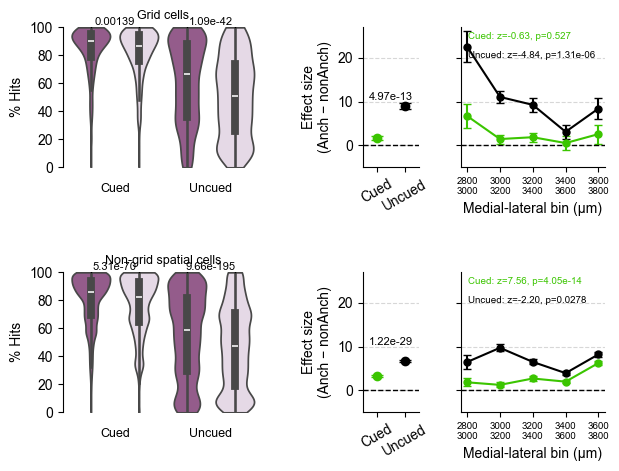

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

order   = ['b, label=1', 'b, label=0', 'nb, label=1', 'nb, label=0']
palette = {
    'b, label=0':  '#e7d7e8', 'b, label=1':  '#9d5391',
    'nb, label=0': '#e7d7e8', 'nb, label=1': '#9d5391',
}
trial_colors = {'Cued': '#3bc500', 'Uncued': 'black'}
sc_bins        = [(2800,3000),(3000,3200),(3200,3400),(3400,3600),(3600,3800)]
sc_bin_labels  = ['2800\n3000','3000\n3200','3200\n3400','3400\n3600','3600\n3800']
sc_bin_centers = [2900, 3100, 3300, 3500, 3700]

def _sem(x):
    x = x.dropna()
    return x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan

def build_df_plot(src):
    records = []
    for _, row in src.iterrows():
        for trial_type in ['b', 'nb']:
            for label in [0, 1]:
                col = f'pct_{trial_type}_{label}'
                if col not in row or pd.isna(row[col]):
                    continue
                records.append({
                    'pct_hits': row[col], 'trial_type': trial_type, 'label': label,
                    'condition': f'{trial_type}, label={label}',
                    'mouse': row.get('mouse', np.nan), 'day': row.get('day', np.nan),
                    'cluster_id': row.get('cluster_id', np.nan),
                })
    df = pd.DataFrame.from_records(records)
    df['condition'] = pd.Categorical(df['condition'], categories=order, ordered=True)
    return df

def fit_lmm_trialtype(df_subset, trial_label):
    df_mod = df_subset.dropna(subset=['pct_hits','mouse','day','cluster_id']).copy()
    if df_mod['label'].nunique() < 2:
        return np.nan, np.nan, np.nan
    try:
        md = smf.mixedlm('pct_hits ~ C(label)', df_mod, groups=df_mod['mouse'],
                         vc_formula={'day':'0+C(day)','cluster':'0+C(cluster_id)'})
        mf = md.fit(reml=False, method='lbfgs')
        term = 'C(label)[T.1]'
        pval = mf.pvalues.get(term, np.nan)
        eff  = mf.params.get(term, np.nan)
        cov  = mf.cov_params()
        se   = np.sqrt(cov.loc[term,term]) if term in cov.index else np.nan
        return pval, eff, se
    except Exception as e:
        print(f"{trial_label}: LMM failed: {e}")
        return np.nan, np.nan, np.nan

def fit_inter_lmm(df_plot):
    df_inter = df_plot.dropna(subset=['pct_hits','mouse','day','cluster_id']).copy()
    df_inter['trial_type'] = pd.Categorical(df_inter['trial_type'], categories=['b','nb'])
    try:
        md = smf.mixedlm('pct_hits ~ C(label)*C(trial_type)', df_inter,
                         groups=df_inter['mouse'],
                         vc_formula={'day':'0+C(day)','cluster':'0+C(cluster_id)'})
        mf = md.fit(reml=False, method='lbfgs')
        term = 'C(label)[T.1]:C(trial_type)[T.nb]'
        return mf.pvalues.get(term, np.nan)
    except:
        return np.nan

def fit_scx_lmm(df_long_trialtype, sc_x_lookup, label_str):
    df_mod = df_long_trialtype.merge(sc_x_lookup, on=['cluster_id','mouse','day'], how='left')
    df_mod = df_mod.dropna(subset=['pct_hits','mouse','day','cluster_id','SC_x']).copy()
    df_mod['SC_x_scaled'] = df_mod['SC_x'] / 200.0
    if len(df_mod) < 10 or df_mod['label'].nunique() < 2:
        return np.nan, np.nan
    try:
        md = smf.mixedlm('pct_hits ~ C(label)*SC_x_scaled', df_mod,
                         groups=df_mod['mouse'],
                         vc_formula={'day':'0+C(day)','cluster':'0+C(cluster_id)'})
        mf = md.fit(reml=False, method='lbfgs')
        term = 'C(label)[T.1]:SC_x_scaled'
        return mf.tvalues.get(term, np.nan), mf.pvalues.get(term, np.nan)
    except Exception as e:
        print(f"{label_str}: SC_x LMM failed: {e}")
        return np.nan, np.nan

def draw_row(ax, ax_eff, ax_bin, src_df, row_title):
    df_plot = build_df_plot(src_df)

    p_b,  eff_b,  se_b  = fit_lmm_trialtype(df_plot[df_plot['trial_type']=='b'],  f'{row_title} Cued')
    p_nb, eff_nb, se_nb = fit_lmm_trialtype(df_plot[df_plot['trial_type']=='nb'], f'{row_title} Uncued')
    p_inter = fit_inter_lmm(df_plot)

    # --- violin ---
    sns.violinplot(data=df_plot, x='condition', y='pct_hits', order=order,
                   palette=palette, inner='box', cut=0, ax=ax)
    ax.set_ylabel('% Hits')
    ax.set_ylim(0, 100)
    ax.set_xticks([]); ax.spines['bottom'].set_visible(False); ax.set_xlabel('')
    ax.set_title(row_title, fontsize=9)
    for xt, lbl in [(0.5,'Cued'),(2.5,'Uncued')]:
        ax.text(xt, -20, lbl, ha='center', va='bottom', fontsize=9)
    for x1, x2, pv in [(0,1,p_b),(2,3,p_nb)]:
        ax.plot([x1,x1,x2,x2],[100,103,103,100], color='k', lw=1)
        ax.text((x1+x2)/2, 100, f"{pv:.3g}" if not np.isnan(pv) else "NA",
                ha='center', va='bottom', fontsize=8)
    sns.despine(ax=ax, bottom=True)

    # --- effect size ---
    for xi, (eff, se, lbl) in enumerate([(eff_b,se_b,'Cued'),(eff_nb,se_nb,'Uncued')]):
        if not np.isnan(eff):
            ax_eff.errorbar(xi, eff, yerr=(se if not np.isnan(se) else None),
                            fmt='o', color=trial_colors[lbl], capsize=4)
    ax_eff.axhline(0, color='k', ls='--', lw=1)
    ax_eff.set_xticks([0,1]); ax_eff.set_xlim(-0.5,1.5); ax_eff.set_ylim(-5,27)
    ax_eff.set_xticklabels(['Cued','Uncued'], rotation=30)
    ax_eff.set_ylabel('Effect size\n(Anch − nonAnch)')
    ax_eff.grid(axis='y', ls='--', alpha=0.5)
    if not np.isnan(p_inter):
        ax_eff.text(0.5, 10, f"{p_inter:.3g}", ha='center', va='bottom', fontsize=8)
    sns.despine(ax=ax_eff)

    # --- binned SC_x ---
    cells_plot = src_df.copy()
    cells_plot['SC_x'] = np.abs(cells_plot['SC_x']) if 'SC_x' in cells_plot.columns \
                         else np.abs(cells_plot['coord_SCs_x'])
    cells_plot['delta_b']  = cells_plot['pct_b_1'] - cells_plot['pct_b_0']
    cells_plot['delta_nb'] = cells_plot['pct_nb_1'] - cells_plot['pct_nb_0']
    sc_x_lookup = cells_plot[['cluster_id','mouse','day','SC_x']].drop_duplicates()
    z_scx_b,  p_scx_b  = fit_scx_lmm(df_plot[df_plot['trial_type']=='b'],  sc_x_lookup, f'{row_title} Cued')
    z_scx_nb, p_scx_nb = fit_scx_lmm(df_plot[df_plot['trial_type']=='nb'], sc_x_lookup, f'{row_title} Uncued')
    for delta_col, trial_label in [('delta_b','Cued'),('delta_nb','Uncued')]:
        means, sems, xs = [], [], []
        for (lo,hi), center in zip(sc_bins, sc_bin_centers):
            sub = cells_plot[(cells_plot['SC_x']>=lo)&(cells_plot['SC_x']<hi)][delta_col].dropna()
            means.append(sub.mean()); sems.append(_sem(sub)); xs.append(center)
        ax_bin.errorbar(xs, means, yerr=sems, fmt='o-', color=trial_colors[trial_label],
                        capsize=3, lw=1.5, ms=5, label=trial_label)
    ax_bin.axhline(0, color='k', ls='--', lw=1)
    ax_bin.set_xticks(sc_bin_centers); ax_bin.set_xticklabels(sc_bin_labels, fontsize=7)
    ax_bin.set_xlabel('Medial-lateral bin (µm)')
    ax_bin.set_ylim(-5,27); ax_bin.set_yticklabels([])
    ax_bin.grid(axis='y', ls='--', alpha=0.5)
    for i, (z_val, p_val, lbl) in enumerate([(z_scx_b,p_scx_b,'Cued'),(z_scx_nb,p_scx_nb,'Uncued')]):
        if not np.isnan(z_val):
            ax_bin.text(0.05, 0.97-i*0.14, f"{lbl}: z={z_val:.2f}, p={p_val:.3g}",
                        ha='left', va='top', fontsize=7, color=trial_colors[lbl],
                        transform=ax_bin.transAxes)
    sns.despine(ax=ax_bin)

# ── 2-row figure ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(7, 5))
gs  = fig.add_gridspec(2, 4, width_ratios=[2.5,0.2,0.7,1.8], wspace=0.4, hspace=0.75)

for row_idx, (src, title) in enumerate([(gcs_, 'Grid cells'), (ngs_, 'Non-grid spatial cells')]):
    ax     = fig.add_subplot(gs[row_idx, 0])
    ax_eff = fig.add_subplot(gs[row_idx, 2])
    ax_bin = fig.add_subplot(gs[row_idx, 3])
    draw_row(ax, ax_eff, ax_bin, src, title)

plt.savefig('correlation_task_anchoring_gcs_ngs.pdf', dpi=300, bbox_inches='tight')
plt.show()



Grid cells Cued SC_x: SC_x interaction LMM summary
                Mixed Linear Model Regression Results
Model:                 MixedLM     Dependent Variable:     pct_hits  
No. Observations:      1336        Method:                 ML        
No. Groups:            8           Scale:                  91.8245   
Min. group size:       22          Log-Likelihood:         -5022.8237
Max. group size:       351         Converged:              Yes       
Mean group size:       167.0                                         
---------------------------------------------------------------------
                           Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                  69.347    8.524  8.136 0.000 52.641 86.053
C(label)[T.1]               6.661    7.900  0.843 0.399 -8.822 22.143
SC_x_scaled                 0.588    0.503  1.170 0.242 -0.397  1.573
C(label)[T.1]:SC_x_scaled  -0.301    0.477 -0.632 0.52

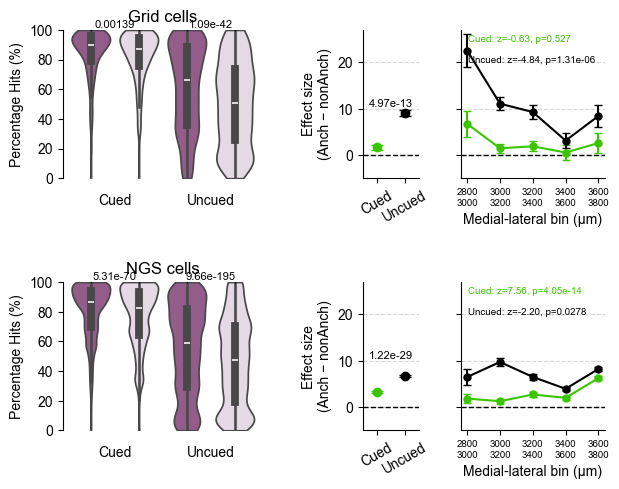

: 

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

trial_colors = {'Cued': '#3bc500', 'Uncued': 'black'}

sc_bins       = [(2800, 3000), (3000, 3200), (3200, 3400), (3400, 3600), (3600, 3800)]
sc_bin_labels = ['2800\n3000', '3000\n3200', '3200\n3400', '3400\n3600', '3600\n3800']
sc_bin_centers = [2900, 3100, 3300, 3500, 3700]

def _sem(x):
    x = x.dropna()
    return x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan


def build_records(df):
    records = []
    for _, row in df.iterrows():
        for trial_type in ['b', 'nb']:
            for label in [0, 1]:
                col = f'pct_{trial_type}_{label}'
                if col not in row or pd.isna(row[col]):
                    continue
                records.append({
                    'pct_hits': row[col],
                    'trial_type': trial_type,
                    'label': label,
                    'condition': f'{trial_type}, label={label}',
                    'mouse': row.get('mouse', np.nan),
                    'day': row.get('day', np.nan),
                    'cluster_id': row.get('cluster_id', np.nan),
                })
    return pd.DataFrame.from_records(records)


def fit_lmm(df_subset, label_str):
    df_mod = df_subset.dropna(subset=['pct_hits', 'mouse', 'day', 'cluster_id']).copy()
    if df_mod['label'].nunique() < 2:
        return np.nan, np.nan, np.nan
    try:
        md = smf.mixedlm(
            'pct_hits ~ C(label)',
            df_mod,
            groups=df_mod['mouse'],
            vc_formula={'day': '0 + C(day)', 'cluster': '0 + C(cluster_id)'},
        )
        m_fit = md.fit(reml=False, method='lbfgs')
        term = 'C(label)[T.1]'
        pval   = m_fit.pvalues.get(term, np.nan)
        effect = m_fit.params.get(term, np.nan)
        cov    = m_fit.cov_params()
        se     = np.sqrt(cov.loc[term, term]) if term in cov.index else np.nan
        return pval, effect, se
    except Exception as e:
        print(f"{label_str}: LMM failed: {e}")
        return np.nan, np.nan, np.nan


def fit_interaction_lmm(df_plot):
    df_inter = df_plot.dropna(subset=['pct_hits', 'mouse', 'day', 'cluster_id']).copy()
    df_inter['trial_type'] = pd.Categorical(df_inter['trial_type'], categories=['b', 'nb'])
    try:
        md = smf.mixedlm(
            'pct_hits ~ C(label) * C(trial_type)',
            df_inter,
            groups=df_inter['mouse'],
            vc_formula={'day': '0 + C(day)', 'cluster': '0 + C(cluster_id)'},
        )
        m_fit = md.fit(reml=False, method='lbfgs')
        term = 'C(label)[T.1]:C(trial_type)[T.nb]'
        return m_fit.pvalues.get(term, np.nan), m_fit.params.get(term, np.nan)
    except Exception as e:
        print(f"Interaction LMM failed: {e}")
        return np.nan, np.nan


def fit_scx_lmm(df_long_trialtype, sc_x_lookup, label_str):
    """Interaction LMM: pct_hits ~ C(label) * SC_x_scaled.

    Tests whether medial-lateral position (SC_x) modulates the anchoring effect
    (label=1 vs label=0). Uses 2 rows per cell (both labels), so cluster_id can
    be included as a VC — more principled than regressing pre-computed deltas.

    sc_x_lookup: DataFrame with columns [cluster_id, mouse, day, SC_x].
    Returns (z, p) for the interaction term C(label)[T.1]:SC_x_scaled.
    """
    df_mod = df_long_trialtype.merge(sc_x_lookup, on=['cluster_id', 'mouse', 'day'], how='left')
    df_mod = df_mod.dropna(subset=['pct_hits', 'mouse', 'day', 'cluster_id', 'SC_x']).copy()
    df_mod['SC_x_scaled'] = df_mod['SC_x'] / 200.0  # coefficient = change per 200 µm bin
    if len(df_mod) < 10 or df_mod['label'].nunique() < 2:
        return np.nan, np.nan
    try:
        md = smf.mixedlm(
            'pct_hits ~ C(label) * SC_x_scaled',
            df_mod,
            groups=df_mod['mouse'],
            vc_formula={'day': '0 + C(day)', 'cluster': '0 + C(cluster_id)'},
        )
        m_fit = md.fit(reml=False, method='lbfgs')
        print(f"\n{label_str}: SC_x interaction LMM summary")
        print(m_fit.summary())
        term = 'C(label)[T.1]:SC_x_scaled'
        return m_fit.tvalues.get(term, np.nan), m_fit.pvalues.get(term, np.nan)
    except Exception as e:
        print(f"{label_str}: SC_x LMM failed: {e}")
        return np.nan, np.nan


def draw_three_panel(ax, ax_eff, ax_bin, df_cells, cell_label):
    order   = ['b, label=1', 'b, label=0', 'nb, label=1', 'nb, label=0']
    palette = {
        'b, label=0':  '#e7d7e8',
        'b, label=1':  '#9d5391',
        'nb, label=0': '#e7d7e8',
        'nb, label=1': '#9d5391',
    }

    df_plot = build_records(df_cells)
    df_plot['condition'] = pd.Categorical(df_plot['condition'], categories=order, ordered=True)

    # LMMs
    p_b,  eff_b,  se_b  = fit_lmm(df_plot[df_plot['trial_type'] == 'b'],  f'{cell_label} Beaconed')
    p_nb, eff_nb, se_nb = fit_lmm(df_plot[df_plot['trial_type'] == 'nb'], f'{cell_label} Non-beaconed')
    p_inter, _          = fit_interaction_lmm(df_plot)

    # ── Violin ──────────────────────────────────────────────────────────
    sns.violinplot(data=df_plot, x='condition', y='pct_hits', order=order,
                   palette=palette, inner='box', cut=0, ax=ax)
    ax.set_ylabel('Percentage Hits (%)')
    ax.set_ylim(0, 100)
    ax.set_xticks([])
    ax.spines['bottom'].set_visible(False)
    ax.set_xlabel('')
    ax.set_title(cell_label)

    y_label_pos = -20
    ax.text(0.5, y_label_pos, 'Cued',   ha='center', va='bottom', fontsize=10)
    ax.text(2.5, y_label_pos, 'Uncued', ha='center', va='bottom', fontsize=10)

    for x1, x2, p_val in [(0, 1, p_b), (2, 3, p_nb)]:
        ax.plot([x1, x1, x2, x2], [100, 103, 103, 100], color='k', linewidth=1.0)
        ax.text((x1 + x2) / 2, 100,
                f"{p_val:.3g}" if not np.isnan(p_val) else "NA",
                ha='center', va='bottom', fontsize=8)

    sns.despine(ax=ax, bottom=True)

    # ── Effect size errorbars ────────────────────────────────────────────
    for xi, (eff, se, lbl) in enumerate([(eff_b, se_b, 'Cued'), (eff_nb, se_nb, 'Uncued')]):
        if not np.isnan(eff):
            ax_eff.errorbar(xi, eff, yerr=(se if not np.isnan(se) else None),
                            fmt='o', color=trial_colors[lbl], capsize=4)
    ax_eff.axhline(0, color='k', linestyle='--', linewidth=1)
    ax_eff.set_xticks([0, 1])
    ax_eff.set_xlim(-0.5, 1.5)
    ax_eff.set_ylim(-5, 27)
    ax_eff.set_xticklabels(['Cued', 'Uncued'], rotation=30)
    ax_eff.set_ylabel('Effect size\n(Anch − nonAnch)')
    ax_eff.grid(axis='y', linestyle='--', alpha=0.5)
    sns.despine(ax=ax_eff)

    if not np.isnan(p_inter):
        ax_eff.text(0.5, 10, f"{p_inter:.3g}", ha='center', va='bottom', fontsize=8)

    # ── Binned SC_x errorbars ────────────────────────────────────────────
    cells_plot = df_cells.copy()
    cells_plot['SC_x'] = np.abs(cells_plot['SC_x']) if 'SC_x' in cells_plot.columns \
                         else np.abs(cells_plot['coord_SCs_x'])
    cells_plot['delta_b']  = cells_plot['pct_b_1'] - cells_plot['pct_b_0']
    cells_plot['delta_nb'] = cells_plot['pct_nb_1'] - cells_plot['pct_nb_0']

    # SC_x interaction LMM: does SC_x modulate the anchoring effect?
    sc_x_lookup = cells_plot[['cluster_id', 'mouse', 'day', 'SC_x']].drop_duplicates()
    z_scx_b,  p_scx_b  = fit_scx_lmm(df_plot[df_plot['trial_type'] == 'b'],  sc_x_lookup, f'{cell_label} Cued SC_x')
    z_scx_nb, p_scx_nb = fit_scx_lmm(df_plot[df_plot['trial_type'] == 'nb'], sc_x_lookup, f'{cell_label} Uncued SC_x')

    for delta_col, trial_label in [('delta_b', 'Cued'), ('delta_nb', 'Uncued')]:
        means, sems, xs = [], [], []
        for (lo, hi), center in zip(sc_bins, sc_bin_centers):
            sub = cells_plot[(cells_plot['SC_x'] >= lo) & (cells_plot['SC_x'] < hi)][delta_col].dropna()
            means.append(sub.mean())
            sems.append(_sem(sub))
            xs.append(center)
        ax_bin.errorbar(xs, means, yerr=sems, fmt='o-', color=trial_colors[trial_label],
                        capsize=3, linewidth=1.5, markersize=5, label=trial_label)

    ax_bin.axhline(0, color='k', linestyle='--', linewidth=1)
    ax_bin.set_xticks(sc_bin_centers)
    ax_bin.set_xticklabels(sc_bin_labels, fontsize=7)
    ax_bin.set_xlabel('Medial-lateral bin (µm)')
    ax_bin.set_ylim(-5, 27)
    ax_bin.set_yticklabels([])
    ax_bin.grid(axis='y', linestyle='--', alpha=0.5)
    sns.despine(ax=ax_bin)

    # Annotate SC_x LMM z-statistic and p-value
    for i, (z_val, p_val, lbl) in enumerate(
            [(z_scx_b, p_scx_b, 'Cued'), (z_scx_nb, p_scx_nb, 'Uncued')]):
        if not np.isnan(z_val):
            ax_bin.text(
                0.05, 0.97 - i * 0.14,
                f"{lbl}: z={z_val:.2f}, p={p_val:.3g}",
                ha='left', va='top', fontsize=7,
                color=trial_colors[lbl],
                transform=ax_bin.transAxes,
            )


# ── Build figure: 2 rows (GCS / NGS), each with 4-column GridSpec ─────────
fig = plt.figure(figsize=(7, 5.2))
gs = fig.add_gridspec(2, 4, width_ratios=[2.5, 0.2, 0.7, 1.8],
                      wspace=0.4, hspace=0.7)

for row, (df_cells, cell_label) in enumerate([(gcs_, 'Grid cells'), (ngs_, 'NGS cells')]):
    ax     = fig.add_subplot(gs[row, 0])
    ax_eff = fig.add_subplot(gs[row, 2])
    ax_bin = fig.add_subplot(gs[row, 3])
    draw_three_panel(ax, ax_eff, ax_bin, df_cells, cell_label)

plt.savefig('correlation_of_task_anchoring_gcs_ngs.pdf', dpi=300, bbox_inches='tight')
plt.show()
